In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, chi2, f_classif
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

In [ ]:
def load_dataset(path):
    df=pd.read_csv(path)
    print("\nDataset loaded successfully")

    print(f"\n10 rows:\n{df.head(10)}")
    rows,cols = df.shape
    print(f"\nshape: {df.shape}")
    print(f"rows: {rows}")
    print(f"columns: {cols}")

    print("\nfeature Names:")
    for col in df.columns:
        print(f"{col}")

    print("\ndatatypes:")
    print(df.dtypes)

    print("\nmissing values:")
    print(df.isnull().sum())

    print("\nduplicate rows:",df.duplicated().sum())

    print("\ndataset Info:")
    df.info()

    print("\nsummary:")
    print(df.describe(include='all'))

    return df

In [ ]:
def detect_dataset_type(data):
    if isinstance(data, pd.DataFrame):
        print("Type: Tabular Dataset")
        return "tabular"

    elif isinstance(data, np.ndarray):
        if data.ndim >= 3:
            print("Type: Image Dataset")
            return "image"

    return "unknown"

In [ ]:
def tabular_eda(df,target_column):
    print("\nTabluar Visualization")

    numeric_df = df.select_dtypes(include=['number'])

    missing = df.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False)

    plt.figure(figsize=(16,12))
    missing.plot(kind='bar', color='skyblue')
    plt.title("Missing Values per Feature")
    plt.xlabel("Features")
    plt.ylabel("Number of Missing Values")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


    if not numeric_df.empty:
        print("\nCorrelation Matrix")
        print(numeric_df.corr())

        plt.figure(figsize=(20,25))
        sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
        plt.title("Correlation Heatmap")
        plt.show()

        numeric_df.hist(figsize=(16,16))
        plt.suptitle("Histograms")
        plt.show()

        plt.figure(figsize=(6,4))
        sns.countplot(x=target_column, data=df)
        plt.title("Class Distribution")
        plt.xlabel(target_column)
        plt.ylabel("Count")
        plt.show()

        for column in numeric_df.columns:
            plt.figure(figsize=(10,5))
            sns.boxplot(x=df[column])
            plt.title(f"Boxplot - {column}")
            plt.show()

        if len(numeric_df.columns) >= 2:
            plt.figure(figsize=(10,5))
            plt.scatter(numeric_df.iloc[:,0], numeric_df.iloc[:,1])
            plt.xlabel(numeric_df.columns[0])
            plt.ylabel(numeric_df.columns[1])
            plt.title("Scatter Plot")
            plt.show()
    categorical_df = df.select_dtypes(exclude=["number"])

    if not categorical_df.empty:
      print("\nCategorical Columns:")

      for col in categorical_df.columns:
          print(f"\n{col}")
          print(df[col].value_counts())

          if df[col].nunique() <= 20:
              plt.figure(figsize=(16,12))
              sns.countplot(data=df, x=col)
              plt.xticks(rotation=45)
              plt.tight_layout()
              plt.show()

In [ ]:
def image_eda(images, labels):

    print("\nImage Visualization")
    print(f"\nNumber of Images: {len(images)}")
    print(f"Image Shape: {images.shape[1:]}")
    print(f"Classes: {len(set(labels))}")

    plt.figure(figsize=(16,12))

    for i in range(10):
        plt.subplot(2,5,i+1)
        plt.imshow(images[i], cmap='gray')
        plt.title(labels[i])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8,4))

    unique, counts = np.unique(labels, return_counts=True)

    plt.bar(unique, counts)

    plt.title("Class Distribution")
    plt.xlabel("Class")
    plt.ylabel("Frequency")
    plt.show()

    plt.figure(figsize=(6,4))
    plt.hist(images.ravel(), bins=50)
    plt.title("Pixel Intensity Distribution")
    plt.xlabel("Pixel Value")
    plt.ylabel("Frequency")
    plt.show()

In [ ]:
def preprocess_tabular(df, target_column):
    print("\nPreprocessing:")

    df = df.copy()

    print("\nMissing Values:")

    # Handle missing values except target column
    for column in df.columns:

        if column == target_column:
            continue

        if df[column].dtype == "object":
            df[column] = df[column].fillna(df[column].mode()[0])
        else:
            df[column] = df[column].fillna(df[column].mean())

    # Drop rows where target is missing
    df = df.dropna(subset=[target_column])

    # Convert target to integer for classification
    if pd.api.types.is_numeric_dtype(df[target_column]):
        df[target_column] = df[target_column].astype(int)

    duplicates = df.duplicated().sum()
    if duplicates > 0:
        df.drop_duplicates(inplace=True)

    print(f"Removed {duplicates} duplicate rows.")

    remove_cols = []
    keywords = ["id", "serial", "unnamed"]

    for col in df.columns:

        if col == target_column:
            continue

        col_lower = col.lower()

        if (
            col_lower == "id" or
            col_lower.endswith("_id") or
            col_lower.startswith("id_") or
            col_lower == "serial" or
            col_lower.startswith("unnamed")
        ):
            remove_cols.append(col)

    df.drop(columns=remove_cols, inplace=True, errors="ignore")
    print("Dropped Columns:", remove_cols)

    print("\nEncoding Categorical Columns.")

    encoder = LabelEncoder()

    for col in df.select_dtypes(include=["object"]).columns:
        if col != target_column:
            df[col] = encoder.fit_transform(df[col])

    print("\nStandardizing Numerical Features.")

    scaler = StandardScaler()

    numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()

    if target_column in numeric_cols:
        numeric_cols.remove(target_column)

    df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

    return df

In [ ]:
def preprocess_image(images):
    print("\nImage Preprocessing:")
    images = images.astype(np.float32)
    images /= 255.0
    print("Pixel values normalized.")
    print("Image Shape :", images.shape)
    return images

In [ ]:
def feature_selection(df, target_column, k=5):

    print("Feature Selection:")

    X = df.drop(columns=[target_column])
    y = df[target_column]

    # Keep only numeric feature columns
    X = X.select_dtypes(include=["number"])

    # Remove rows with missing target (extra safety)
    mask = y.notna()
    X = X.loc[mask]
    y = y.loc[mask]

    # Convert target to integer
    if pd.api.types.is_numeric_dtype(y):
        y = y.astype(int)

    if X.empty:
        print("No numerical features available.")
        print("Skipping ANOVA and Chi-Square Feature Selection.")
        return [], []

    print("\nANOVA Feature Selection:")

    anova_selector = SelectKBest(score_func=f_classif, k=k)
    anova_selector.fit(X, y)

    anova_scores = pd.DataFrame({
        "Feature": X.columns,
        "ANOVA Score": anova_selector.scores_
    })

    anova_scores = anova_scores.sort_values(
        by="ANOVA Score",
        ascending=False
    )

    print(anova_scores)

    anova_features = anova_scores.head(k)["Feature"].tolist()

    print("\nTop Features:")
    print(anova_features)

    plt.figure(figsize=(16,12))
    plt.bar(anova_scores["Feature"], anova_scores["ANOVA Score"])
    plt.title("Feature Importance using ANOVA")
    plt.xlabel("Features")
    plt.ylabel("Score")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    print("\nChi-Square Feature Selection:")

    # Chi-Square requires non-negative values
    X_chi = X - X.min()

    chi_selector = SelectKBest(score_func=chi2, k=k)
    chi_selector.fit(X_chi, y)

    chi_scores = pd.DataFrame({
        "Feature": X.columns,
        "Chi2 Score": chi_selector.scores_
    })

    chi_scores = chi_scores.sort_values(
        by="Chi2 Score",
        ascending=False
    )

    print(chi_scores)

    chi_features = chi_scores.head(k)["Feature"].tolist()

    print("\nTop Features:")
    print(chi_features)

    plt.figure(figsize=(16,12))
    plt.bar(chi_scores["Feature"], chi_scores["Chi2 Score"])
    plt.title("Feature Importance using Chi-Square")
    plt.xlabel("Features")
    plt.ylabel("Score")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return anova_features, chi_features

In [ ]:
def split_data(df, target_column):
    print("\nData Splitting:")

    X = df.drop(columns=[target_column])
    y = df[target_column]
    class_counts = y.value_counts()

    if class_counts.min() >= 2:
        stratify = y
    else:
        print("Some classes have fewer than 2 samples. Splitting without stratification.")
        stratify = None

    X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=stratify
)
    temp_counts = y_temp.value_counts()

    if temp_counts.min() >= 2:
        stratify_temp = y_temp
    else:
        print("Validation/Test split without stratification.")
        stratify_temp = None

    X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=stratify_temp
)
    print(f"Training Set   : {X_train.shape[0]}")
    print(f"Validation Set : {X_val.shape[0]}")
    print(f"Testing Set    : {X_test.shape[0]}")

    print("\nFeature Dimensions:")
    print("Training :", X_train.shape)
    print("Validation :", X_val.shape)
    print("Testing :", X_test.shape)

    return X_train, X_val, X_test, y_train, y_val, y_test

In [ ]:
def identify_ml_task(df, target_column=None):
    print("\nML Task Identification:")
    if target_column is None:
        learning_type = "Unsupervised Learning"
        task_type = "Clustering or Dimensionality Reduction"
        print(f"Learning Type : {learning_type}")
        print(f"Task Type     : {task_type}")
        return learning_type, task_type

    learning_type = "Supervised Learning"
    y = df[target_column]
    if y.dtype == "object" or y.nunique() <= 20:
        task_type = "Classification"
    else:
        task_type = "Regression"

    print(f"Target Column : {target_column}")
    print(f"Learning Type : {learning_type}")
    print(f"Task Type     : {task_type}")

    return learning_type, task_type


Dataset loaded successfully

10 rows:
  flower_id  sepal_length  sepal_width  petal_length  petal_width species  \
0         1           5.1          3.5           1.4          0.2  SETOSA   
1       ID2           4.9          3.0           1.4          0.2  Setosa   
2       ID3           4.7          NaN           1.3          NaN  Setosa   
3       ID4           4.6          3.1           1.5          0.2  SETOSA   
4         5           5.0          3.6           1.4          0.2  Setosa   
5         6           NaN          3.9           1.7          0.4  setosa   
6         7           4.6          3.4           1.4          0.3  setosa   
7       ID8           5.0          3.4           1.5          0.2  setosa   
8         9           4.4          2.9           1.4          0.2  setosa   
9      ID10           NaN          3.1           1.5          0.1  Setosa   

   Unnamed: 0  
0         2.0  
1         2.0  
2         NaN  
3         2.0  
4         NaN  
5         NaN  
6

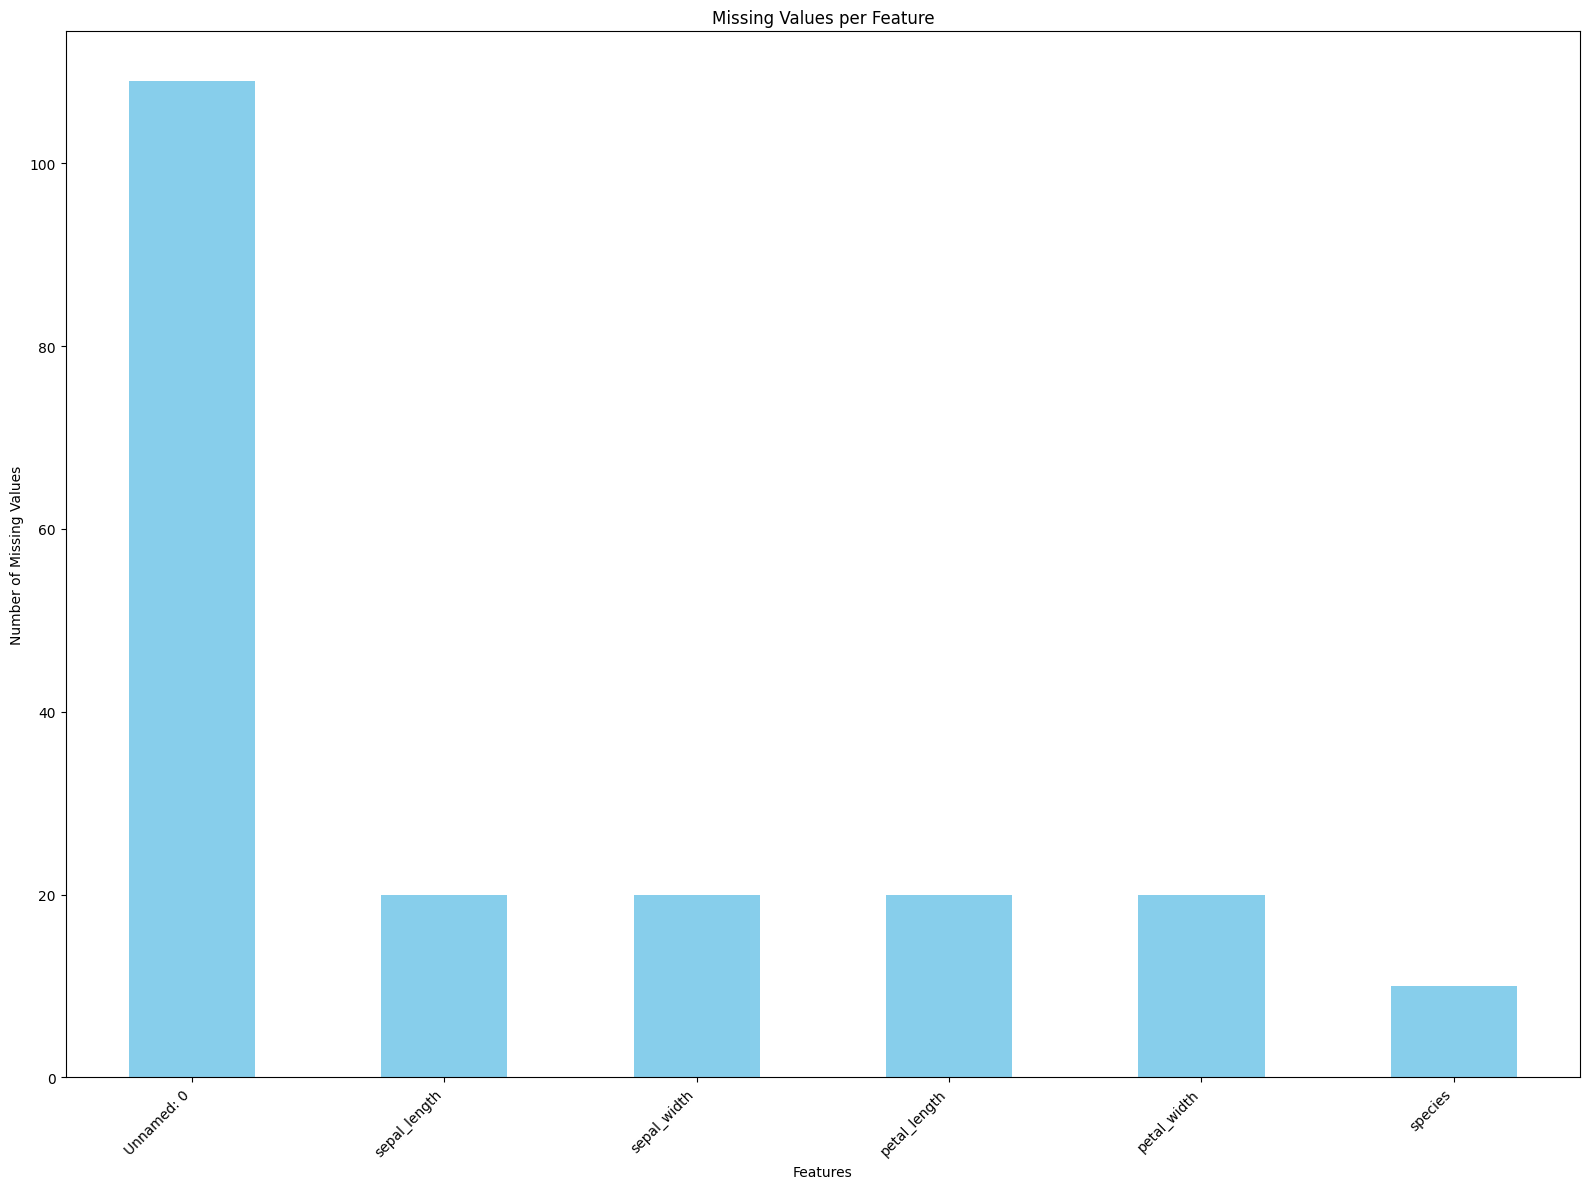


Correlation Matrix
              sepal_length  sepal_width  petal_length  petal_width  Unnamed: 0
sepal_length      1.000000    -0.040569      0.270510     0.130482    0.025898
sepal_width      -0.040569     1.000000     -0.429457    -0.296917   -0.000170
petal_length      0.270510    -0.429457      1.000000     0.642185    0.034936
petal_width       0.130482    -0.296917      0.642185     1.000000    0.058924
Unnamed: 0        0.025898    -0.000170      0.034936     0.058924    1.000000


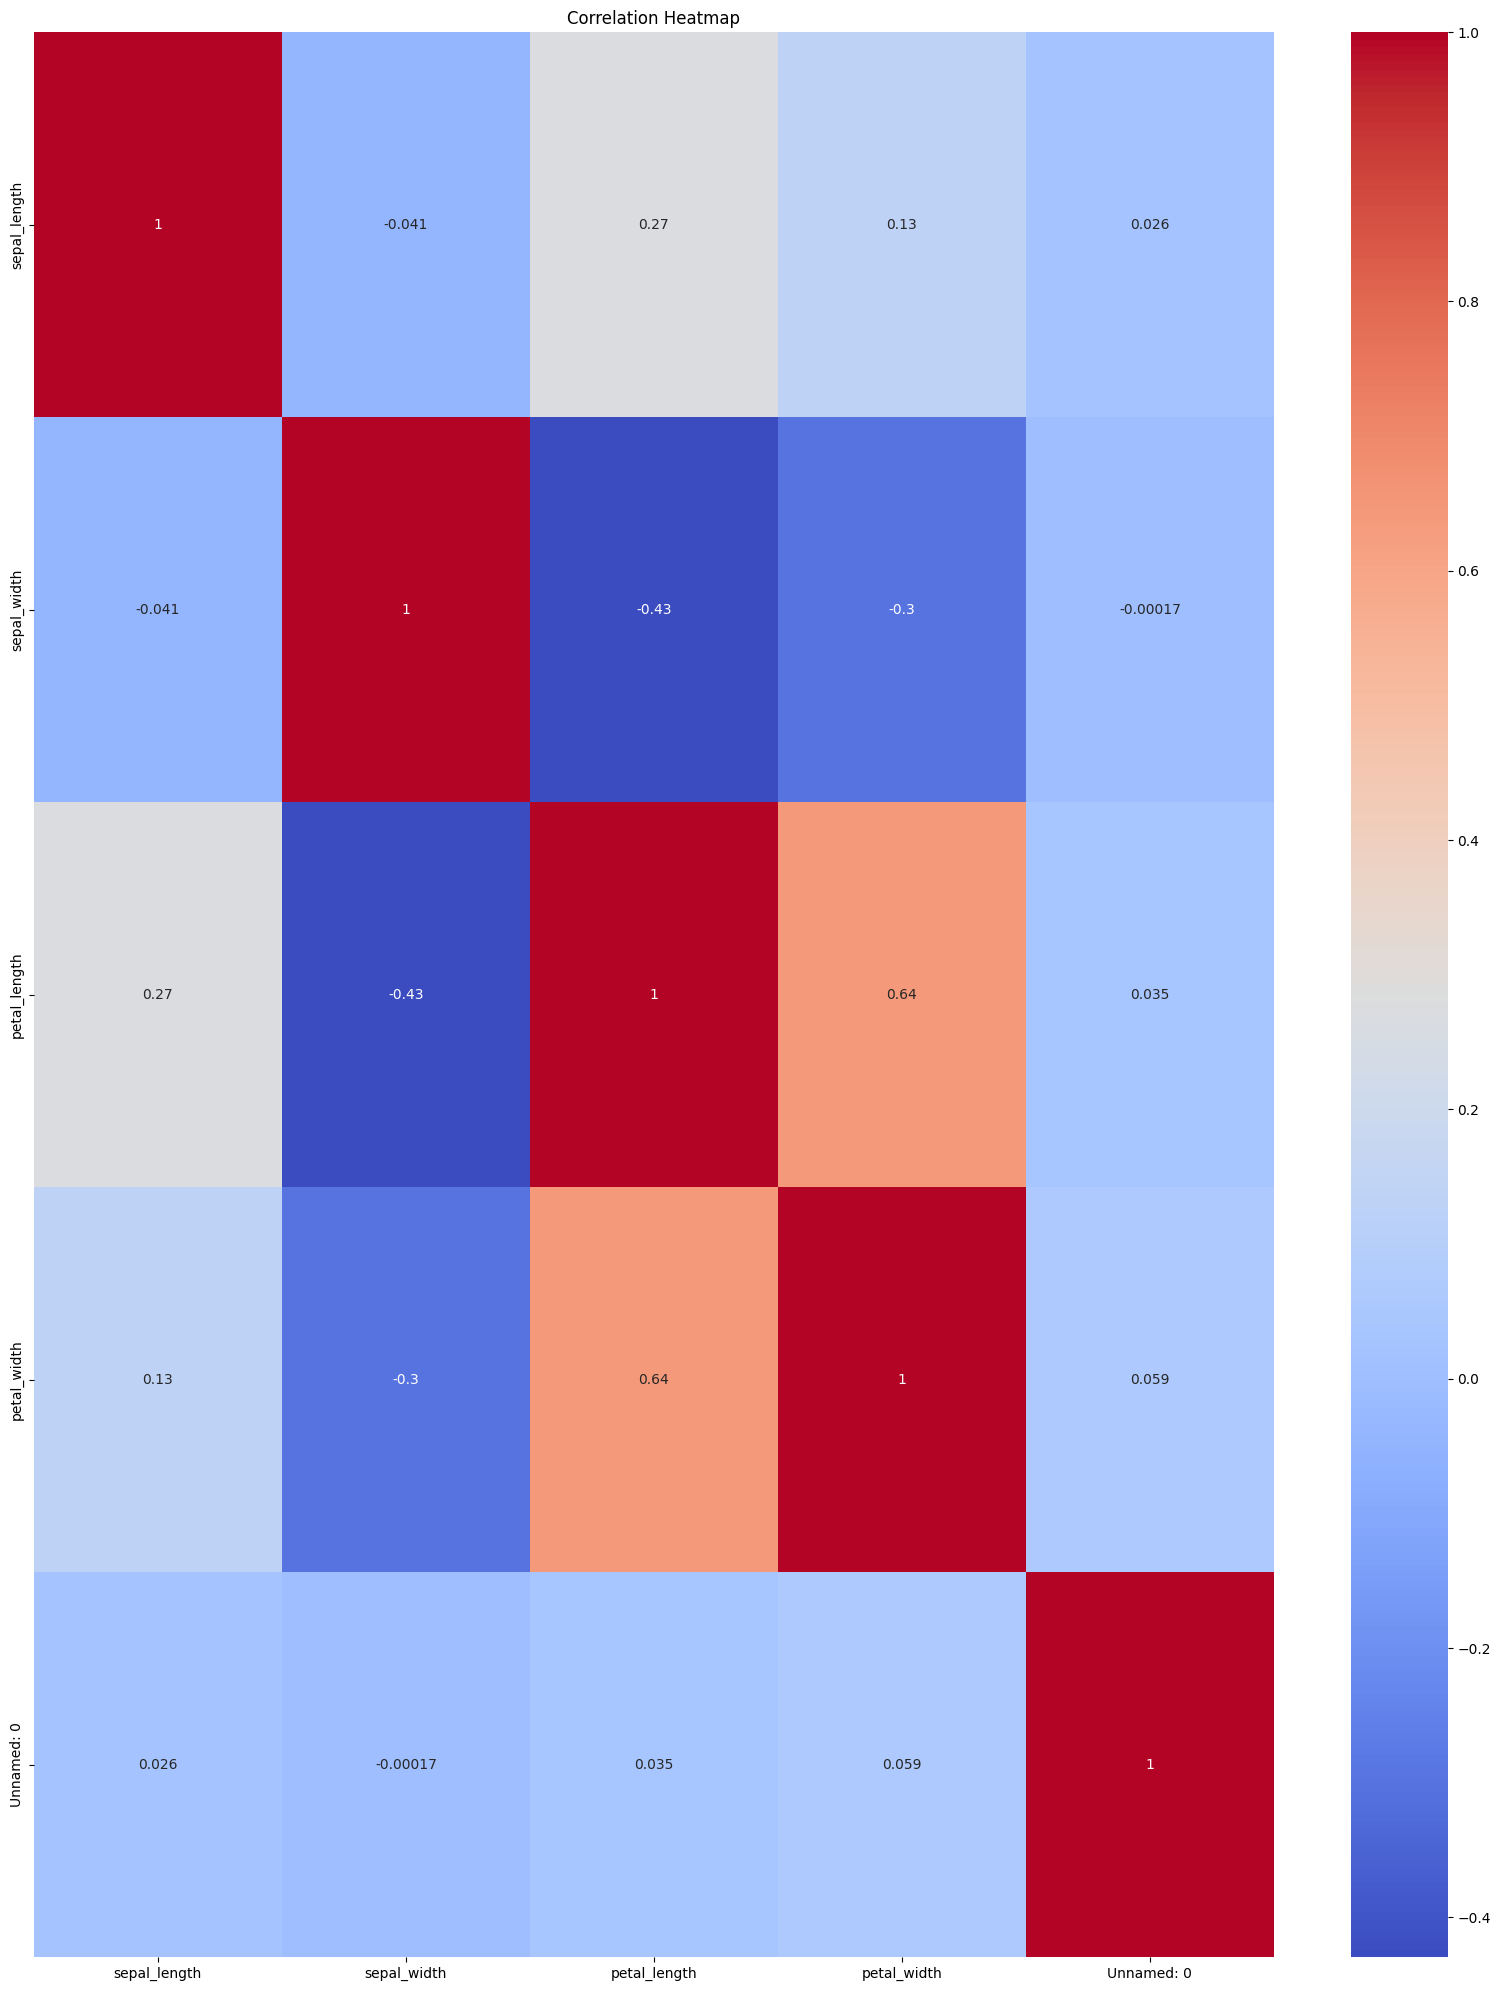

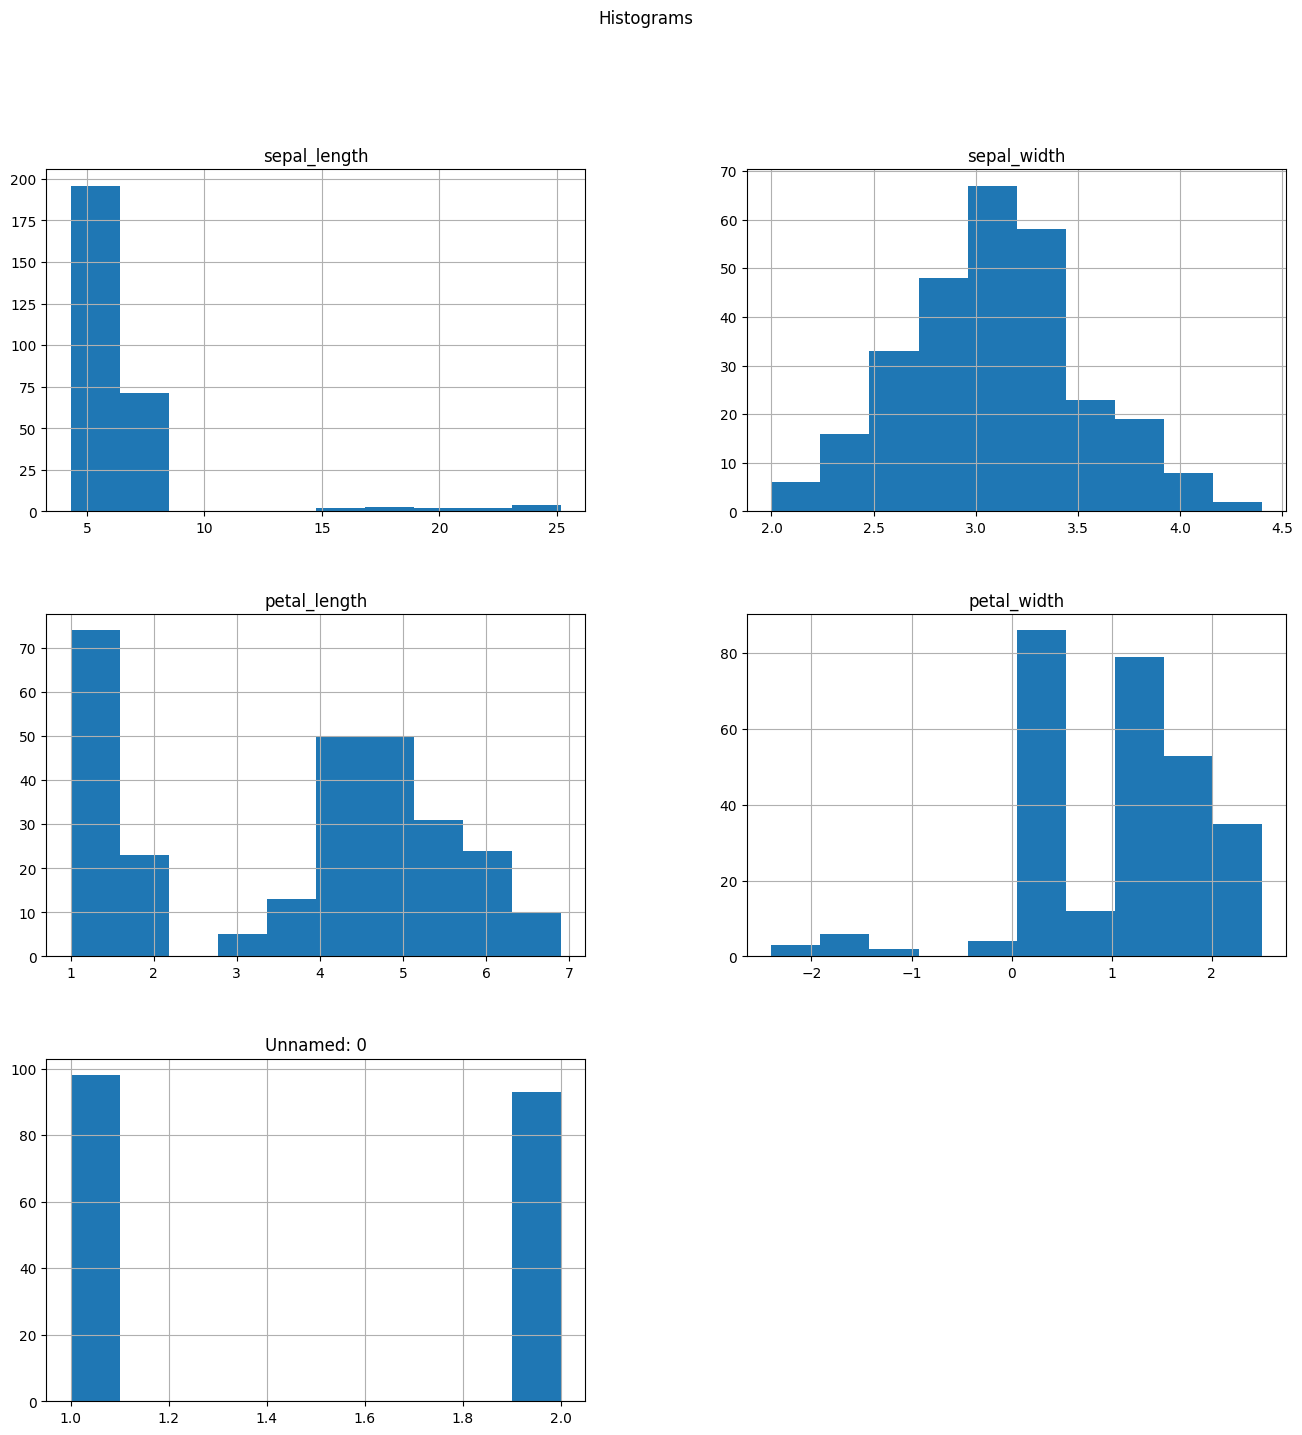

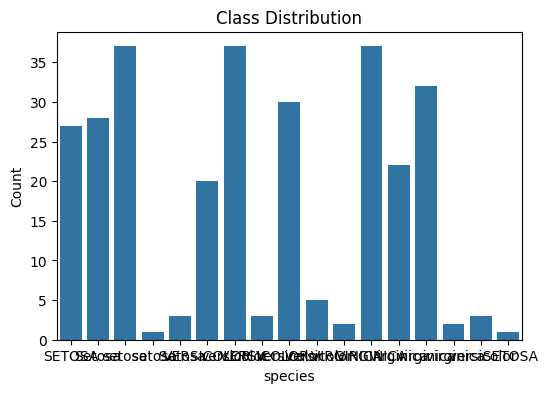

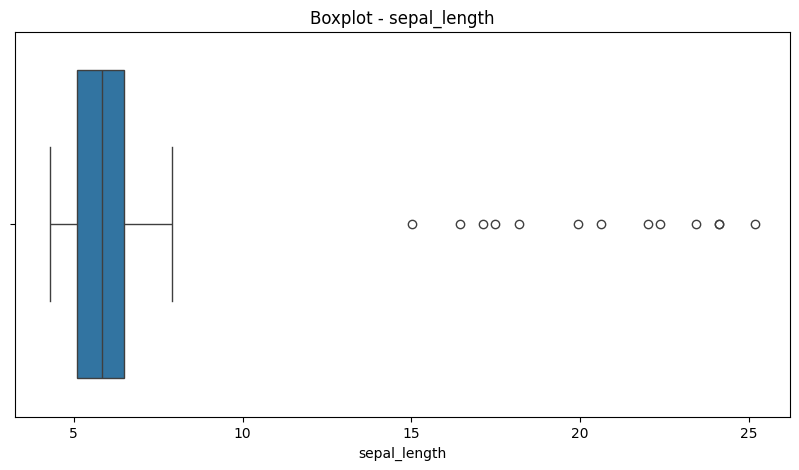

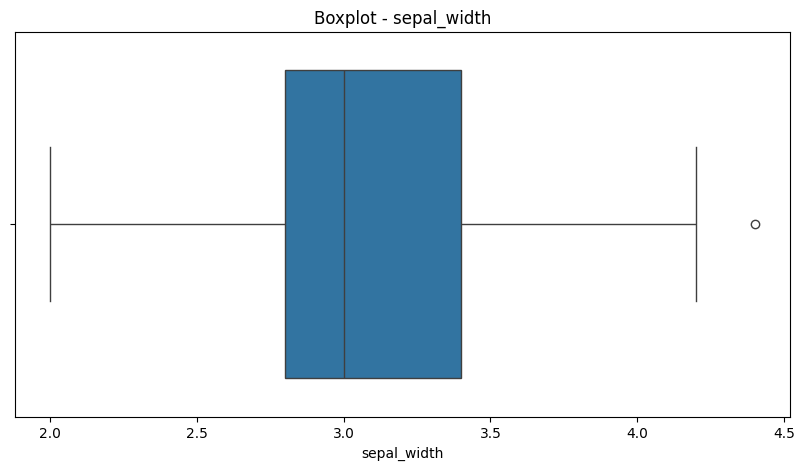

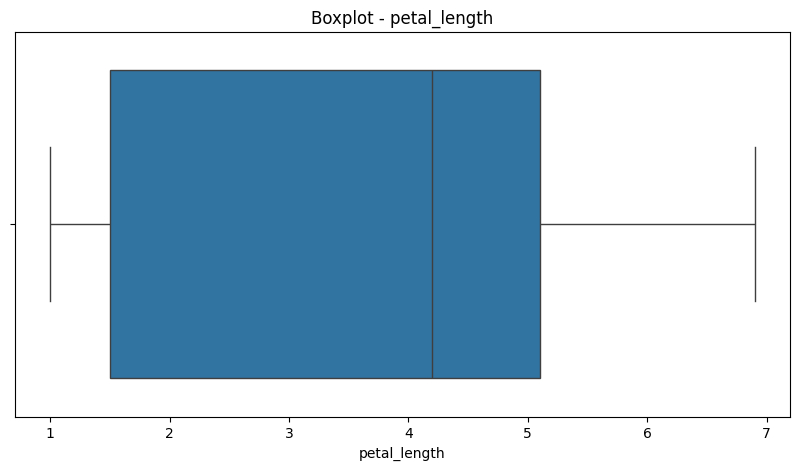

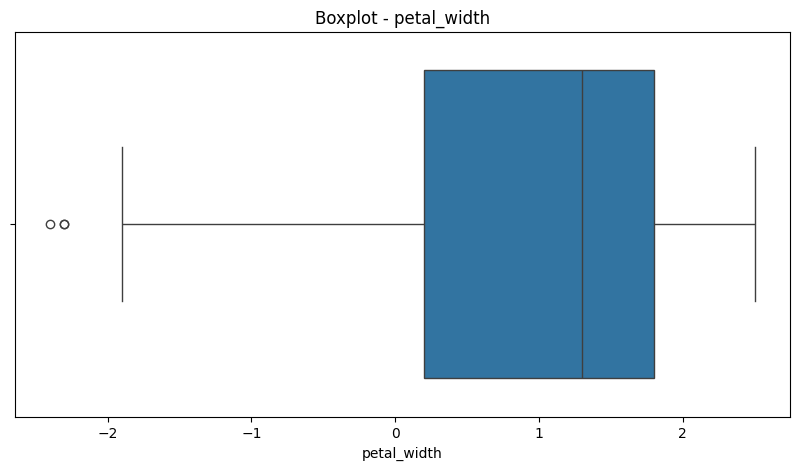

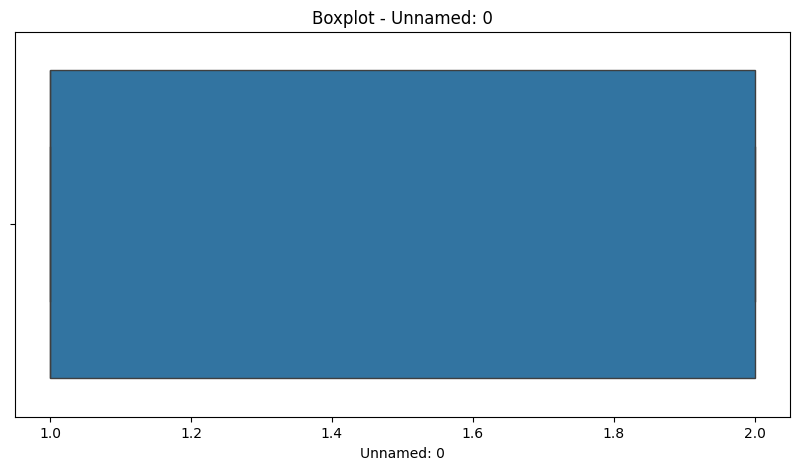

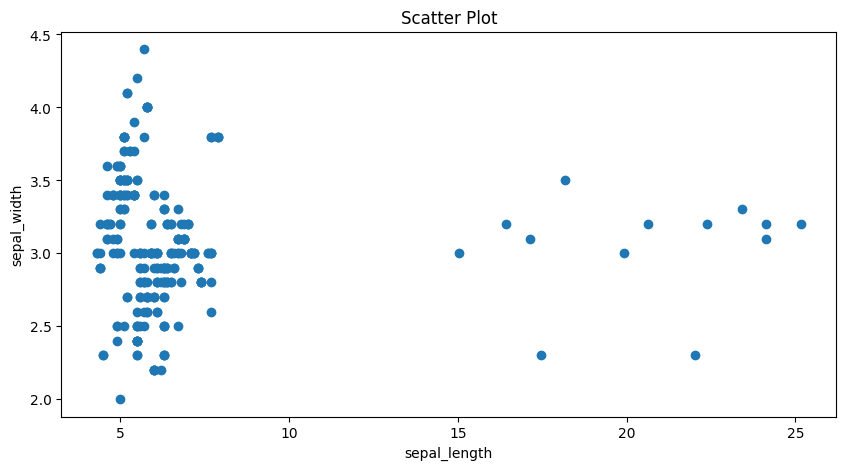


Categorical Columns:

flower_id
flower_id
15       6
ID28     5
103      5
ID53     4
51       4
        ..
144      1
145      1
147      1
148      1
ID149    1
Name: count, Length: 150, dtype: int64

species
species
setosa           37
VIRGINICA        37
versicolor       37
virginica        32
Versicolor       30
Setosa           28
SETOSA           27
Virginica        22
VERSICOLOR       20
  Versicolor      5
  versicolor      3
  Setosa          3
  VERSICOLOR      3
  virginica       2
  VIRGINICA       2
  setosa          1
  SETOSA          1
Name: count, dtype: int64


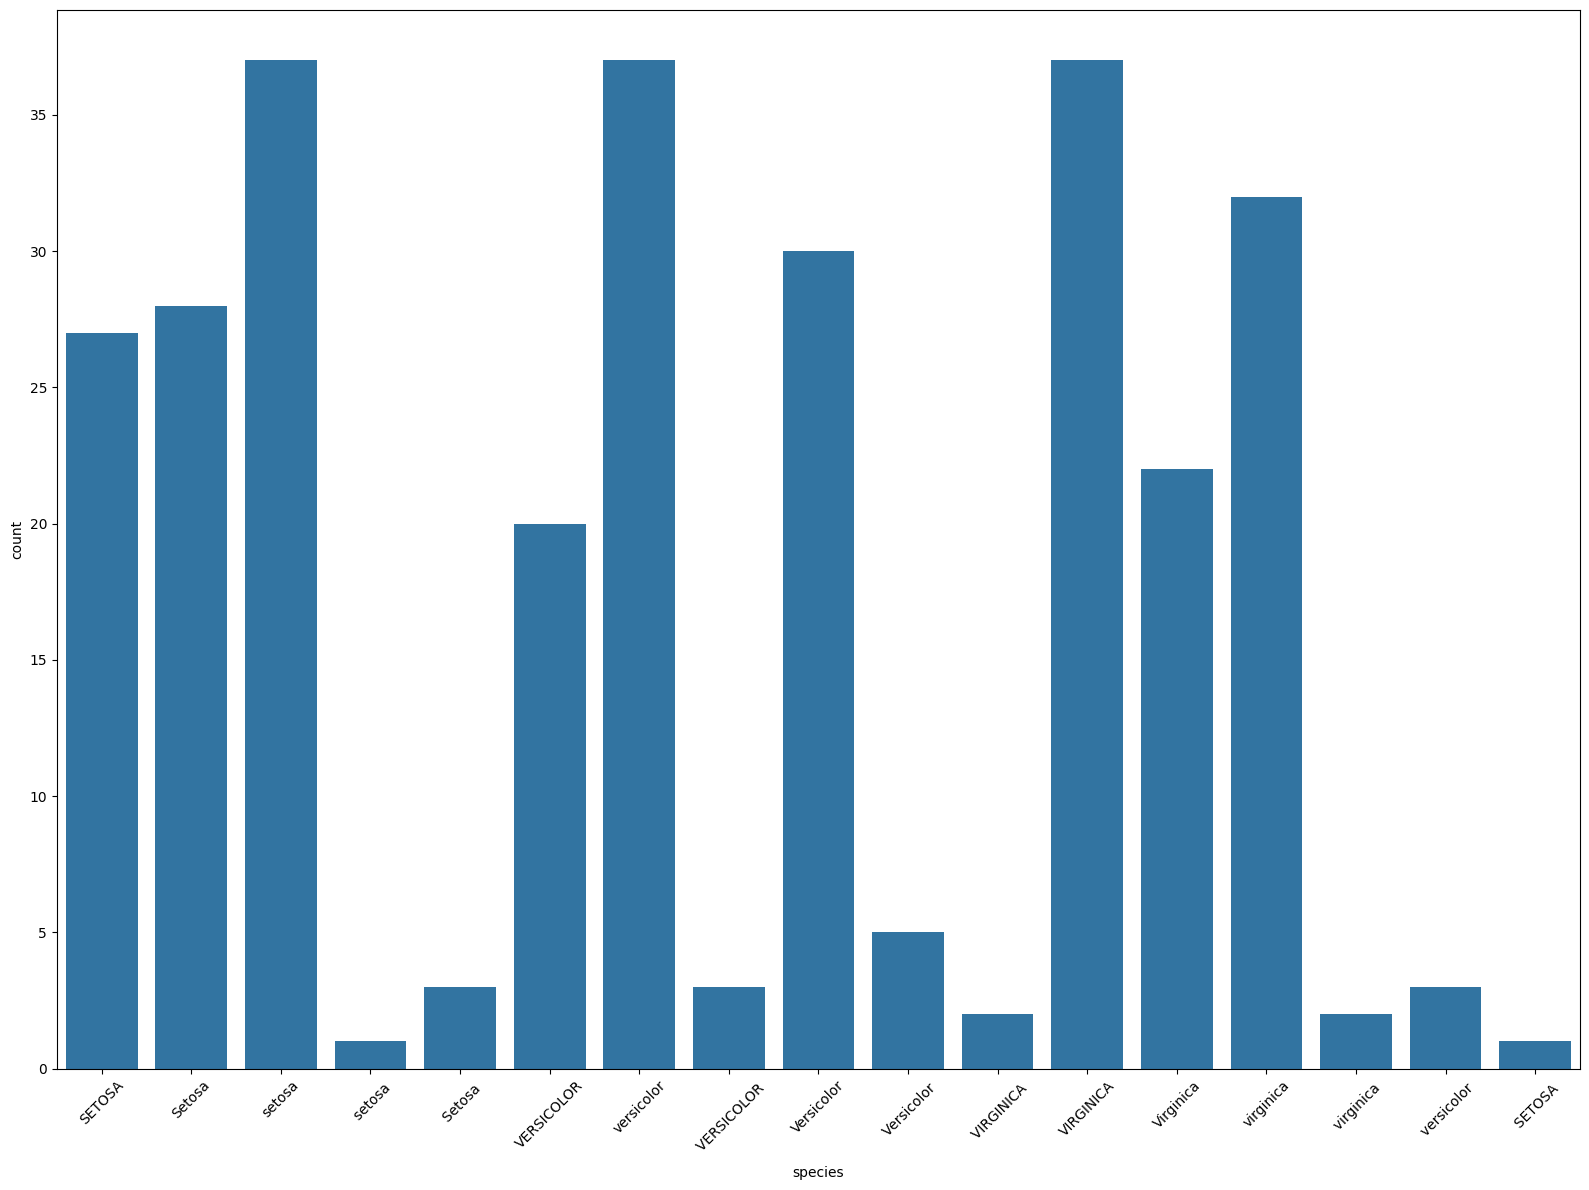


Preprocessing:

Missing Values:
Removed 13 duplicate rows.
Dropped Columns: ['flower_id', 'Unnamed: 0']

Encoding Categorical Columns.

Standardizing Numerical Features.
Feature Selection:

ANOVA Feature Selection:
        Feature  ANOVA Score
2  petal_length   142.946054
1   sepal_width    10.948627
3   petal_width    10.456632
0  sepal_length     2.231708

Top Features:
['petal_length', 'sepal_width', 'petal_width']


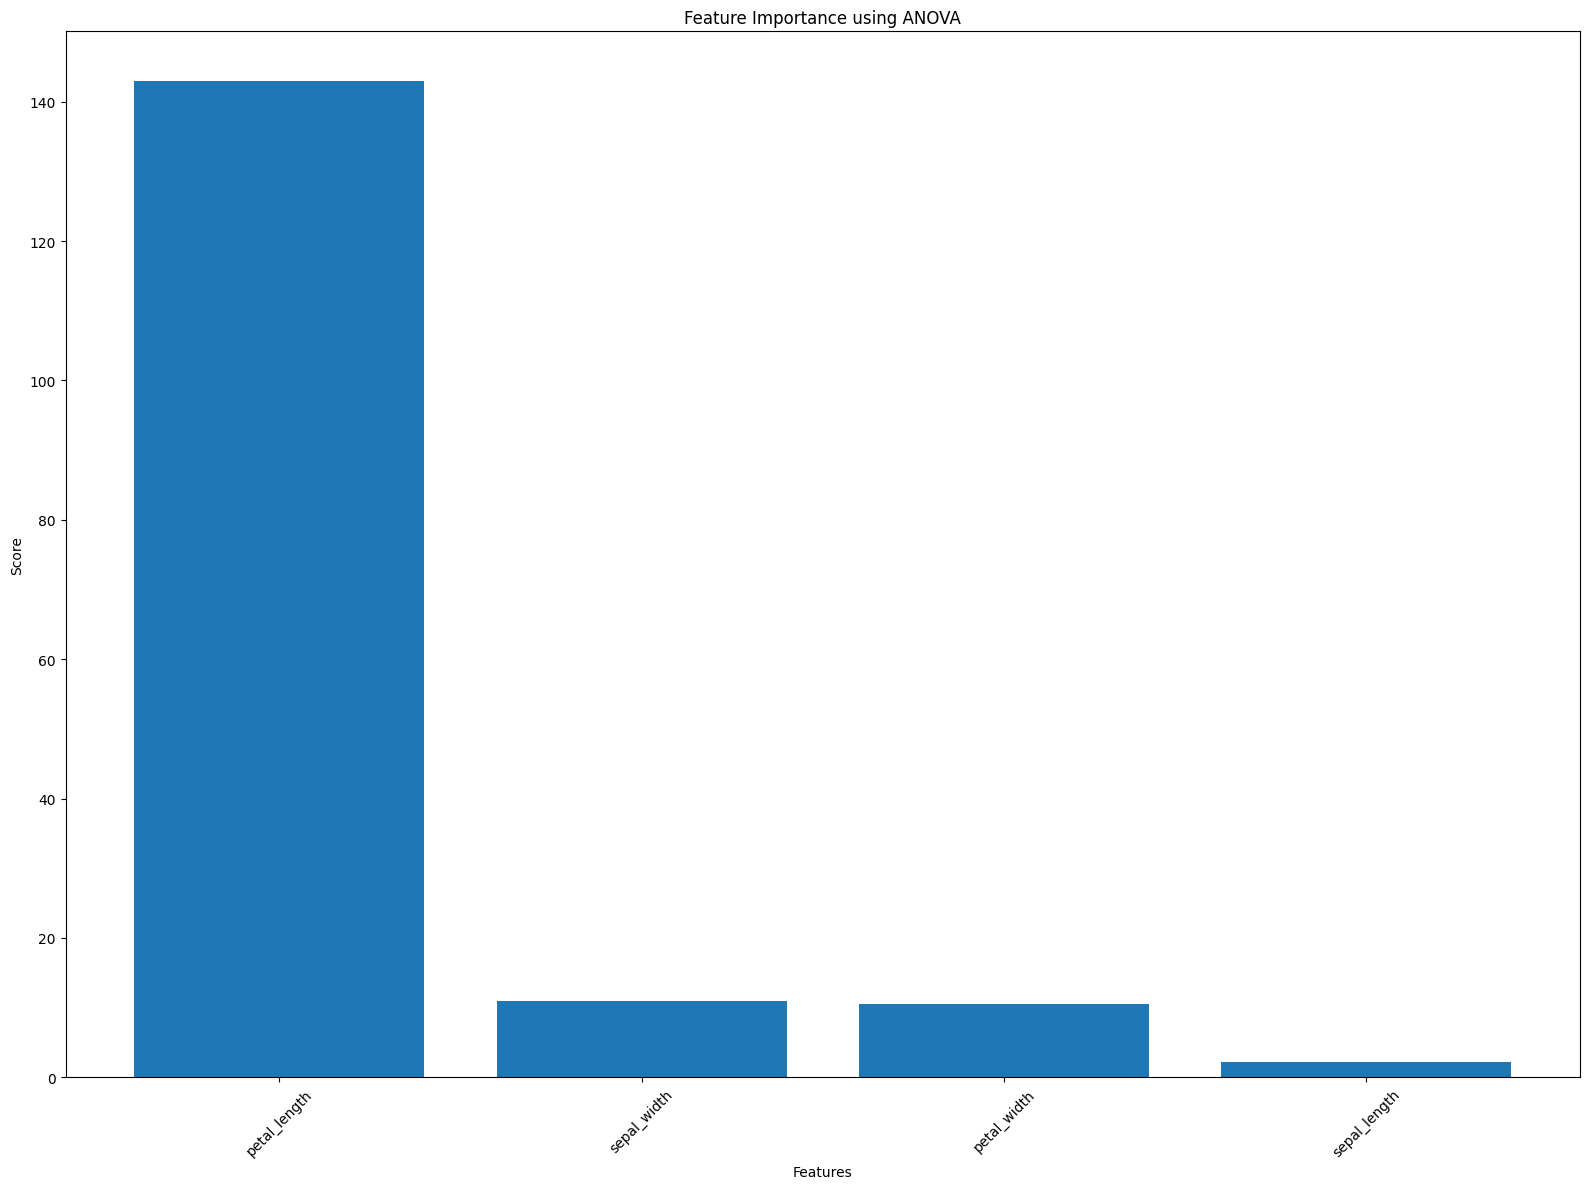


Chi-Square Feature Selection:
        Feature  Chi2 Score
2  petal_length  156.600763
0  sepal_length   47.314313
1   sepal_width   43.171383
3   petal_width   29.321901

Top Features:
['petal_length', 'sepal_length', 'sepal_width']


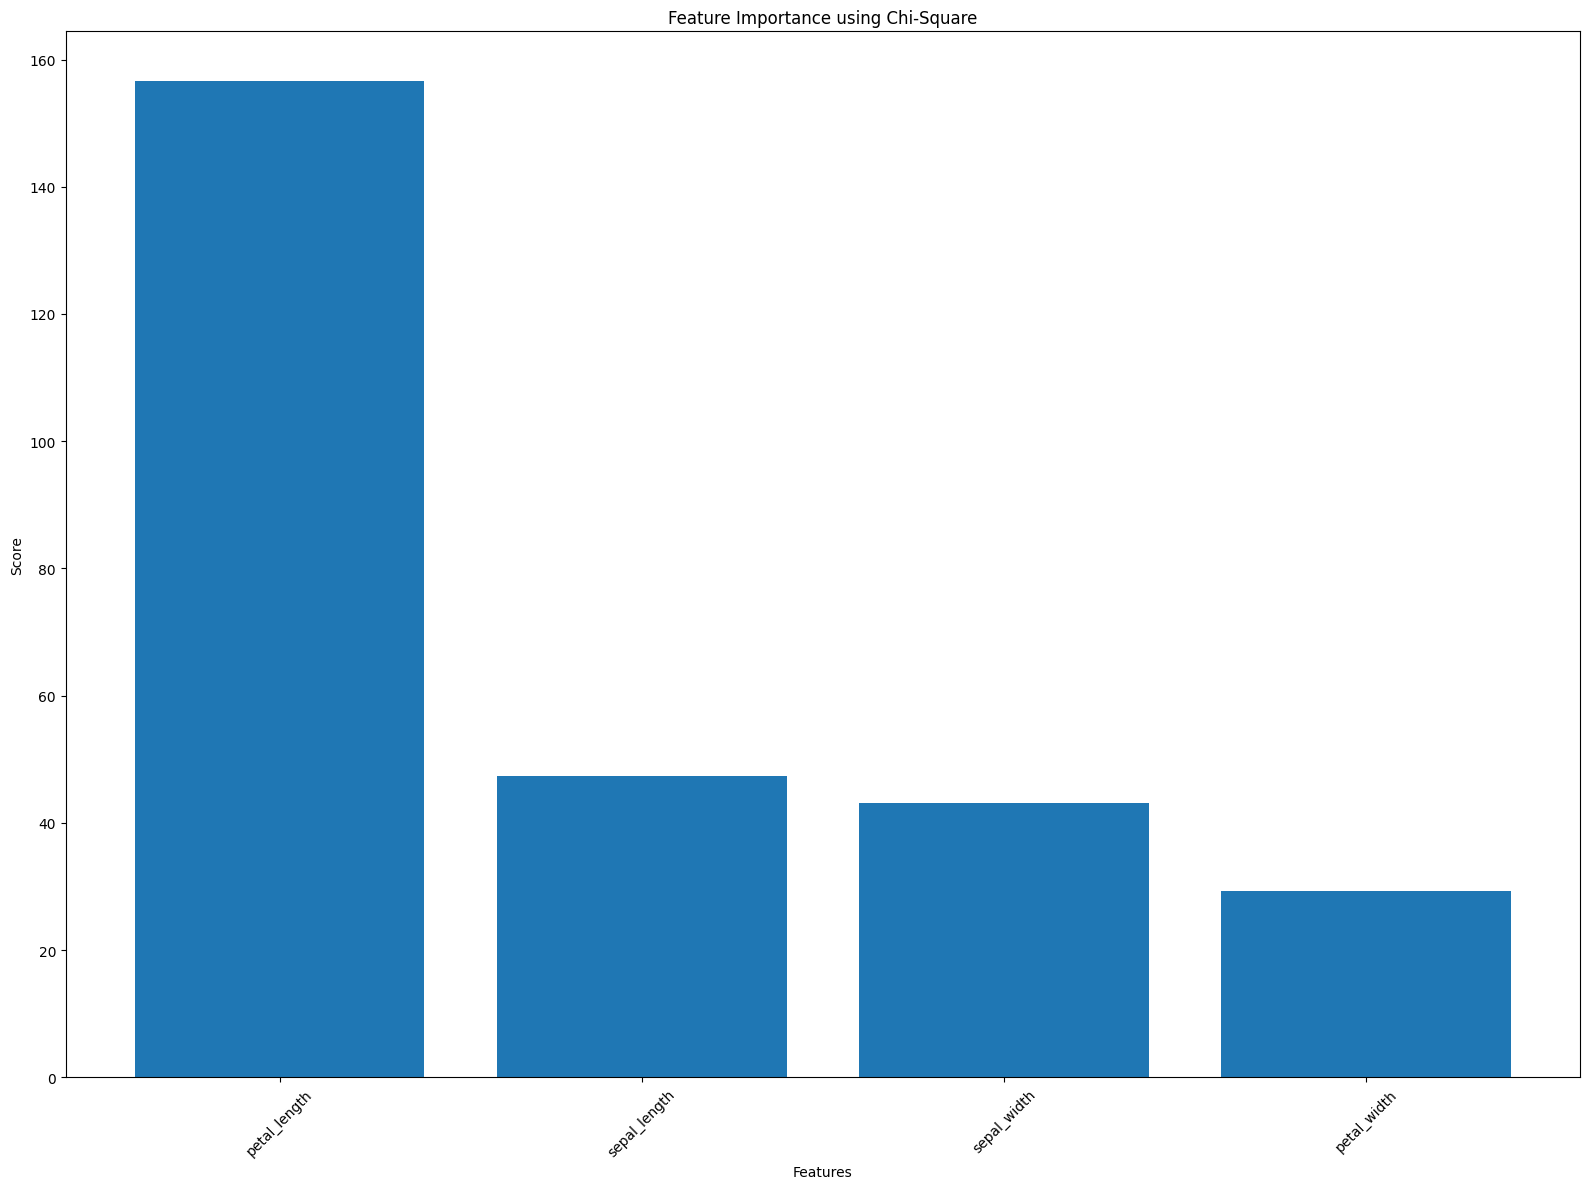


Data Splitting:
Some classes have fewer than 2 samples. Splitting without stratification.
Validation/Test split without stratification.
Training Set   : 193
Validation Set : 42
Testing Set    : 42

Feature Dimensions:
Training : (193, 4)
Validation : (42, 4)
Testing : (42, 4)

ML Task Identification:
Target Column : species
Learning Type : Supervised Learning
Task Type     : Classification
None


In [ ]:
def eda(path):
    df = load_dataset(path)
    print(df.columns.tolist())
    dtype = detect_dataset_type(df)
    if dtype == "tabular":
        tabular_eda(df,"species")
        data = preprocess_tabular(df,"species")
    elif dtype == "image":
        data = preprocess_image(df)
        image_eda(images, labels)
    else:
        print("Unsupported dataset type.")

    anova_features, chi_features = feature_selection(
    data,
    target_column="species",
    k=3
)
    X_train, X_val, X_test, y_train, y_val, y_test = split_data(
    data,
    target_column="species"
)
    identify_ml_task(data, target_column="species")

print(eda("iris_unclean_dataset.csv"))